In [2]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("cleaned_data.csv")

In [6]:
df.head()

,Unnamed: 0,clean_comment,category,word_count,num_stop_words
0,0,family mormon never tried explain still stare ...,1,39,13
1,1,buddhism much lot compatible christianity espe...,1,196,59
2,2,seriously say thing first get complex explain ...,-1,86,40
3,3,learned want teach different focus goal not wr...,0,29,15
4,4,benefit may want read living buddha living chr...,1,112,45


In [8]:
df.drop(columns=["Unnamed: 0"] , inplace=True)

In [10]:
df.head()

,clean_comment,category,word_count,num_stop_words
0,family mormon never tried explain still stare ...,1,39,13
1,buddhism much lot compatible christianity espe...,1,196,59
2,seriously say thing first get complex explain ...,-1,86,40
3,learned want teach different focus goal not wr...,0,29,15
4,benefit may want read living buddha living chr...,1,112,45


In [12]:
df.shape

(36662, 4)

In [14]:
unique_words = set(" ".join(df["clean_comment"]).split())

In [16]:
len(unique_words)

48174

Now we will build a ML model

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
X = df["clean_comment"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
tfidf = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        random_state=42
    )
}

In [27]:
results = []
predictions = {}

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted")
    })
    predictions[name] = y_pred

In [29]:
results

[{'Model': 'Naive Bayes',
  'Accuracy': 0.620619119050866,
  'Precision': 0.7128228359526374,
  'Recall': 0.620619119050866,
  'F1': 0.5874640206278685},
 {'Model': 'Logistic Regression',
  'Accuracy': 0.830765034774308,
  'Precision': 0.8341286040530476,
  'Recall': 0.830765034774308,
  'F1': 0.8254544605133939},
 {'Model': 'Random Forest',
  'Accuracy': 0.7995363425610255,
  'Precision': 0.8085802957135565,
  'Recall': 0.7995363425610255,
  'F1': 0.7858489814870948},
 {'Model': 'Linear SVM',
  'Accuracy': 0.8544933860630028,
  'Precision': 0.85432051439333,
  'Recall': 0.8544933860630028,
  'F1': 0.8518860483786914}]

So Linear SVM was actually performing better than all other models. So now we will plot confusion matrix for this

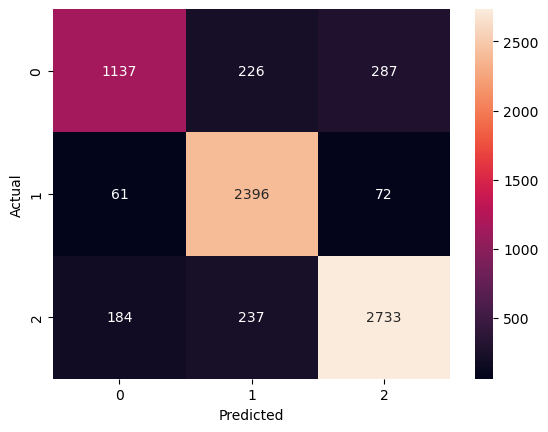

In [32]:
cm = confusion_matrix(y_test, predictions["Linear SVM"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
print(classification_report(y_test , predictions["Linear SVM"]))

              precision    recall  f1-score   support

          -1       0.82      0.69      0.75      1650
           0       0.84      0.95      0.89      2529
           1       0.88      0.87      0.88      3154

    accuracy                           0.85      7333
   macro avg       0.85      0.83      0.84      7333
weighted avg       0.85      0.85      0.85      7333



Well it is actually performing good on positive and neutral class but not that good on negative class it is missing 31% of negative comments

In [37]:
misclassified_idx = y_test != predictions["Linear SVM"]

errors = pd.DataFrame({
    "text": X_test[misclassified_idx],
    "actual": y_test[misclassified_idx],
    "predicted": predictions["Linear SVM"][misclassified_idx]
})

errors[errors["actual"] == -1]

,text,actual,predicted
8660,made analytical skeptical questioning persiste...,-1,1
22124,party take video put campaign advertisement,-1,0
8756,people expect person nationalistic long people...,-1,1
13428,fact random whatsapp forward usual upvoted lib...,-1,1
16302,not sure feel look amazing but time little dis...,-1,1
...,...,...,...
2240,let speak man language choice not good enough ...,-1,1
33661,since ama reddit probably proving point politi...,-1,1
9146,think next big get change government rbi need ...,-1,1
29563,situation different working inc cpi party,-1,0


It is actually missing 513 negative comments and SVM is misclassifying them into positive and neutral

One of the reasons was we have less negative comments in our data

In [41]:
pipeline = Pipeline([
    ("tfidf" , TfidfVectorizer()),
    ("svm" , LinearSVC(random_state=42))
])
param_grid = {
    "tfidf__max_features": [5000, 10000, 15000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "svm__C": [0.1, 1, 10]
}

In [43]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'tfidf__max_features': [5000, 10000, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [45]:
print(grid_search.best_params_)

{'svm__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}


In [47]:
print(grid_search.best_score_)

0.8517180996345262


In [49]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [51]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

          -1       0.83      0.69      0.76      1650
           0       0.84      0.95      0.89      2529
           1       0.89      0.87      0.88      3154

    accuracy                           0.86      7333
   macro avg       0.85      0.84      0.84      7333
weighted avg       0.86      0.86      0.85      7333



We got change even though it is tiny

In [54]:
import joblib

joblib.dump(best_model, "svm_model.pkl")

['svm_model.pkl']